In [1]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import mitsuba as mi
import drjit as dr
import torch
import numpy as np
import time
import math
mi.set_variant('cuda_ad_rgb')


import time
from contextlib import contextmanager

@contextmanager
def timer(name = ""):
    start = time.time()
    try:
        yield
    finally:
        end = time.time()
        print(f"{name} Time elapsed: {end - start:.3f} seconds")

In [2]:
# scene = mi.load_file("assets/sphere_scene.xml", integrator='prb', max_depth=3)
scene = mi.load_file("assets/sphere_scene.xml", integrator='direct')
params = mi.traverse(scene)

In [3]:
# randomly generate some cameras
cameras = []
for _ in range(10):
    x = torch.randn(3)*0.5
    while not 0.4 < x.norm() < 0.7:
        x = torch.randn(3)*0.5
    t = torch.randn(3)*0.3
    while not t.norm() < 0.29:
        t = torch.randn(3)*0.3
    cameras.append({'to_world': mi.Transform4f.look_at(origin=x.numpy(), target=t.numpy(), up=[0, 1, 0]), 'x_fov': 60, 'lightpos':x.numpy()})

# collocated light
def setcamera(params, cam1, update=True):
    params['PerspectiveCamera.x_fov'] = cam1['x_fov']
    params['PerspectiveCamera.to_world'] = cam1['to_world']
    params['PointLight.position'] = cam1['lightpos']
    if update:
        params.update()

In [4]:
# Render ground truth images
GT_imgs = []
for i,cam in enumerate(tqdm(cameras)):
    setcamera(params, cam)
    GT_imgs.append(mi.render(scene, params, spp=32))

  0%|          | 0/10 [00:00<?, ?it/s]

In [5]:
param_keys = ['wood_olive_wood_olive_basecolor.data', 'wood_olive_wood_olive_roughness.data']
tex_shape = params[param_keys[0]].shape[:2]
param_dim = sum([params[key].shape[2] for key in param_keys])

def set_param(params, theta, enable_grad=False):
    assert theta.shape == (*tex_shape, param_dim)
    dim_ptr = 0
    for i, key in enumerate(param_keys):
        curr_dim = params[key].shape[2]
        params[key] = type(params[key])(theta[..., dim_ptr:dim_ptr+curr_dim])
        dim_ptr += curr_dim
        if enable_grad:
            dr.enable_grad(params[key])
    assert dim_ptr == param_dim
    params.update()

In [98]:
import random

def to_tuple(a):
    if isinstance(a, tuple):
        return a
    return (a,)
    
def U(theta, camera_ids):
    camera_ids = to_tuple(camera_ids)
    theta_s = theta.sigmoid()
    set_param(params, theta_s)
    # render images and accumulate likelihood to uv-space
    lpdf = 0.0
    for cam_id in camera_ids:
        setcamera(params, cameras[cam_id])
        I = mi.render(scene, params, spp=1, seed=random.randint(0, 2147483647))
        Ierr = I - GT_imgs[cam_id]
        sigma = 0.05
        lpdf += dr.sum(dr.sqr(Ierr) / (2 * sigma**2) + math.log(sigma*math.sqrt(2*math.pi)))
    return lpdf + (theta_s*(1-theta_s)).log()

def dU(theta, camera_ids):
    camera_ids = to_tuple(camera_ids)
    theta_s = theta.sigmoid()
    set_param(params, theta_s, enable_grad=True)
    # render images and accumulate likelihood to uv-space
    lpdf = 0.0
    for cam_id in camera_ids:
        setcamera(params, cameras[cam_id])
        I = mi.render(scene, params, spp=2, seed=random.randint(0, 2147483647))
        dr.backward(dr.sum(dr.sqr(I - GT_imgs[cam_id])))
    param_grad = torch.cat([params[k].grad_().torch() for k in param_keys], axis=-1)
    return param_grad / (2 * 0.05**2) + (1-2*theta_s)

In [86]:

def U_o(theta, camera_ids):
    camera_ids = to_tuple(camera_ids)
    set_param(params, theta)
    # render images and accumulate likelihood to uv-space
    lpdf = 0.0
    for cam_id in camera_ids:
        setcamera(params, cameras[cam_id])
        I = mi.render(scene, params, spp=1, seed=random.randint(0, 2147483647))
        Ierr = I - GT_imgs[cam_id]
        sigma = 0.05
        lpdf += dr.sum(dr.sqr(Ierr) / (2 * sigma**2) + math.log(sigma*math.sqrt(2*math.pi)))
    return lpdf

def dU_o(theta, camera_ids):
    camera_ids = to_tuple(camera_ids)
    set_param(params, theta, enable_grad=True)
    # render images and accumulate likelihood to uv-space
    lpdf = 0.0
    for cam_id in camera_ids:
        setcamera(params, cameras[cam_id])
        I = mi.render(scene, params, spp=2, seed=random.randint(0, 2147483647))
        dr.backward(dr.sum(dr.sqr(I - GT_imgs[cam_id])))
    param_grad = torch.cat([params[k].grad_().torch() for k in param_keys], axis=-1)
    return param_grad / (2 * 0.05**2)

In [87]:
# def prior(x, k=20):
#     return -(1-(2*x-1)**k).log()

# def dprior(x, k=20):
#     return 2*k*(2*x-1)**(k-1) / (1-(2*x-1)**k)

# def prior(x, k=100, thres=0.05):
#     return k*(thres-x).max(0.0) + k*(x-1+thres).max(0.0)

# def dprior(x, k=100, thres=0.05):
#     return -k * (x<thres) + k * (x>1-thres)

def prior(x, k=2000, thres=0.05):
    return k*(thres-x).clamp(max=0.0)**2 + k*(x-1+thres).clamp(max=0.0)**2

def dprior(x, k=2000, thres=0.05):
    return 2*k*(x-thres).clamp(min=0.0) + 2*k*(x-1+thres).clamp(max=0.0)

    
def U_p(theta, camera_ids):
    camera_ids = to_tuple(camera_ids)
    set_param(params, theta)
    # render images and accumulate likelihood to uv-space
    lpdf = 0.0
    for cam_id in camera_ids:
        setcamera(params, cameras[cam_id])
        I = mi.render(scene, params, spp=1, seed=random.randint(0, 2147483647))
        Ierr = I - GT_imgs[cam_id]
        sigma = 0.05
        lpdf += dr.sum(dr.sqr(Ierr) / (2 * sigma**2) + math.log(sigma*math.sqrt(2*math.pi)))
    return lpdf + prior(theta)

def dU_p(theta, camera_ids):
    camera_ids = to_tuple(camera_ids)
    set_param(params, theta, enable_grad=True)
    # render images and accumulate likelihood to uv-space
    lpdf = 0.0
    for cam_id in camera_ids:
        setcamera(params, cameras[cam_id])
        I = mi.render(scene, params, spp=2, seed=random.randint(0, 2147483647))
        dr.backward(dr.sum(dr.sqr(I - GT_imgs[cam_id])))
    param_grad = torch.cat([params[k].grad_().torch() for k in param_keys], axis=-1)
    return param_grad / (2 * 0.05**2) + dprior(theta)

## Stochastic gradient descent

  0%|          | 0/50 [00:00<?, ?it/s]

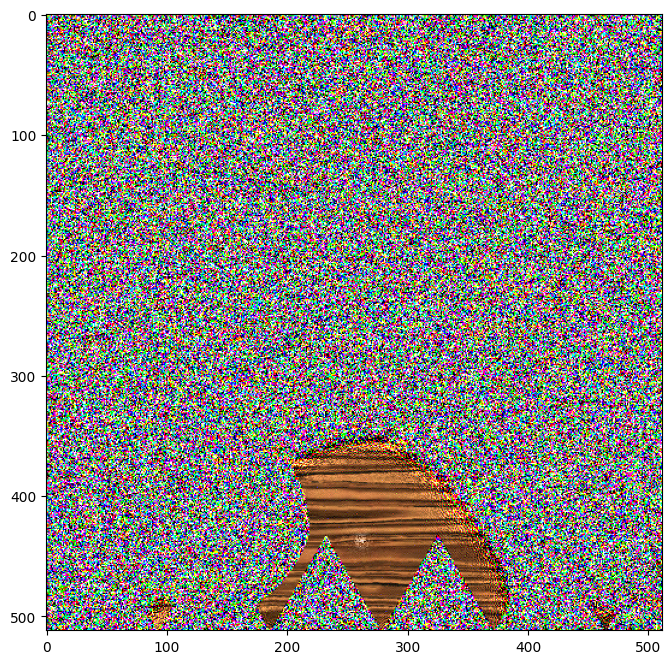

In [125]:
def GD(camera_ids, n_iter=200):
    x = torch.rand((*tex_shape, param_dim), device='cuda').logit()
    g2 = torch.zeros((*tex_shape, param_dim), device='cuda')
    beta = 0.95
    for it in tqdm(range(n_iter)):
        g = dU(x, camera_ids=camera_ids)
        g2 = beta * g2 + (1-beta) * g**2
        # print(x, g)
        x -= 0.12 * g / (1e-6 + g2.sqrt())
    return x

x1 = GD(0, n_iter=50).sigmoid()
plt.figure(figsize=(8,8))
plt.imshow(x1.cpu()[...,0:3])

  0%|          | 0/50 [00:00<?, ?it/s]

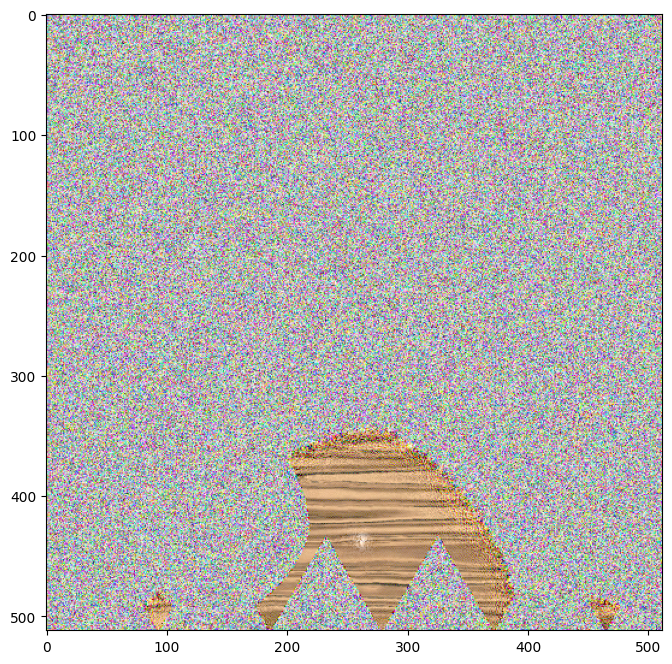

In [127]:
def GD_o(camera_ids, n_iter=200):
    x = torch.rand((*tex_shape, param_dim), device='cuda')
    g2 = torch.zeros((*tex_shape, param_dim), device='cuda')
    beta = 0.95
    for it in tqdm(range(n_iter)):
        g = dU_o(x, camera_ids=camera_ids)
        g2 = beta * g2 + (1-beta) * g**2
        x -= 0.02 * g / (1e-6 + g2.sqrt())
        x = x.clamp(min=0, max=1)
    return x

x1 = GD_o(0, n_iter=50)
plt.figure(figsize=(8,8))
plt.imshow(x1.cpu()[...,0:3]**0.454)

  0%|          | 0/200 [00:00<?, ?it/s]

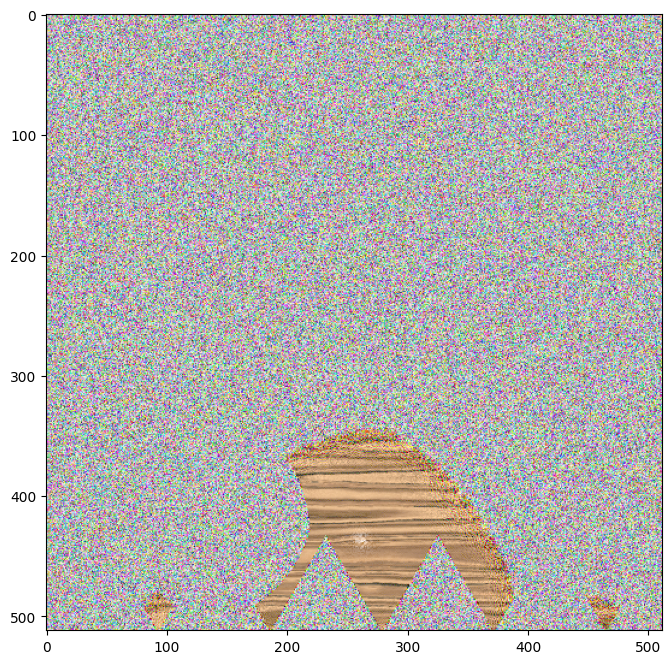

In [106]:
def GD_o(camera_ids, n_iter=200):
    x = torch.rand((*tex_shape, param_dim), device='cuda')
    g2 = torch.zeros((*tex_shape, param_dim), device='cuda')
    beta = 0.95
    for it in tqdm(range(n_iter)):
        g = dU_o(x, camera_ids=camera_ids)
        g2 = beta * g2 + (1-beta) * g**2
        x -= 0.005 * g / (1e-6 + g2.sqrt())
        x = x.clamp(min=0, max=1)
    return x

x1 = GD_o(0, n_iter=200)
plt.figure(figsize=(8,8))
plt.imshow(x1.cpu()[...,0:3]**0.454)

In [52]:
def GD_p(camera_ids, n_iter=200):
    x = torch.rand((*tex_shape, param_dim), device='cuda')
    g2 = torch.zeros((*tex_shape, param_dim), device='cuda')
    beta = 0.95
    for it in tqdm(range(n_iter)):
        g = dU_p(x, camera_ids=camera_ids)
        g2 = beta * g2 + (1-beta) * g**2
        x -= 0.01 * g / (1e-6 + g2.sqrt())
        x = x.clamp(min=0, max=1)
    return x

  0%|          | 0/100 [00:00<?, ?it/s]

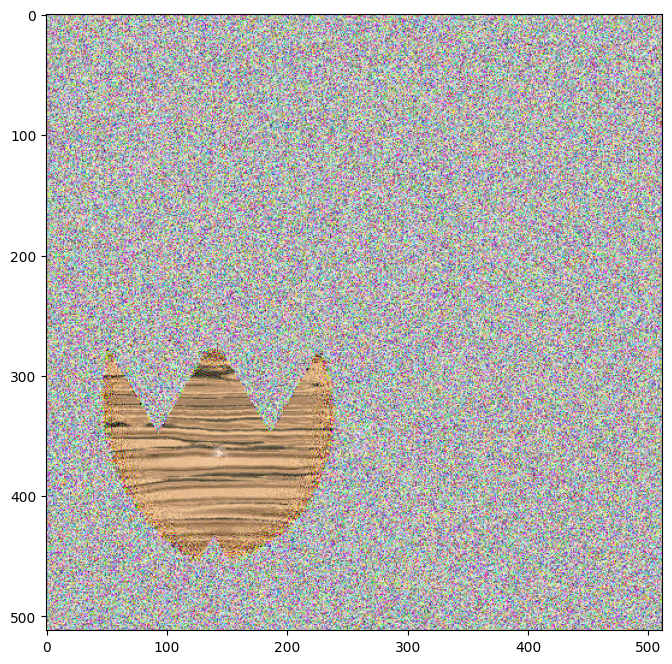

In [53]:
x2 = GD_p(0, n_iter=100)
plt.figure(figsize=(8, 8))
plt.imshow(x1.cpu()[...,0:3]**0.454)

In [54]:
print((x1==0.0).sum(), (x2==0.0).sum())
print((x1==1.0).sum(), (x2==1.0).sum())

tensor(2712, device='cuda:0') tensor(0, device='cuda:0')
tensor(402, device='cuda:0') tensor(0, device='cuda:0')


In [93]:
x1.isnan().any()

tensor(False, device='cuda:0')

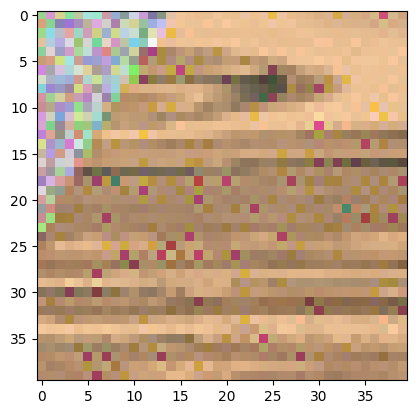

In [95]:

plt.imshow(x1.cpu()[300:340,200:240,0:3]**0.454)

In [98]:

x1[320,217,0:3]

tensor([0.3986, 0.0486, 0.1702], device='cuda:0')

In [105]:
dprior(torch.tensor([0.00001]))

tensor([-99841.2500])